**Preprocessing Dataset**

In [95]:
import os
import json
from tqdm import tqdm

RAW_DIR = "data/raw/Dataset"
SOURCES_FILE = "data/raw/sources.json"
OUTPUT_FILE = "data/processed/afnd_clean.jsonl"

def load_source_labels():
    with open(SOURCES_FILE, "r", encoding="utf-8") as f:
        sources = json.load(f)
    return sources  # {"source_1": "credible", ...}

def preprocess():
    sources = load_source_labels()
    out = open(OUTPUT_FILE, "w", encoding="utf-8")

    article_id = 0

    for source_folder in tqdm(os.listdir(RAW_DIR)):
        src_path = os.path.join(RAW_DIR, source_folder, "scraped_articles.json")
        if not os.path.exists(src_path):
            continue

        label_raw = sources.get(source_folder)

        # Skip undecided sources
        if label_raw == "undecided":
            continue

        # Convert to binary labels
        label = 1 if label_raw == "credible" else 0

        with open(src_path, "r", encoding="utf-8") as f:
            articles = json.load(f)
            # print(articles) # Removed print for clean execution

        # --- MODIFICATION 1: Correctly access the list of articles ---
        if isinstance(articles, dict) and 'articles' in articles:
            article_list = articles['articles']
        elif isinstance(articles, list):
            article_list = articles
        else:
            print(f"Skipping {src_path}: unexpected JSON structure.")
            continue

        for art in article_list:
            # --- MODIFICATION 2: Fix getstr to use standard dict.get() ---
            text = art.get("text", "").strip()
            title = art.get("title", "").strip()

            if len(text) < 30:
                continue  # skip empty or tiny articles

            record = {
                "id": article_id,
                "source": source_folder,
                "label": label,
                "title": title,
                "text": text
            }

            out.write(json.dumps(record, ensure_ascii=False) + "\n")
            article_id += 1

    out.close()
    print("DONE. Written:", OUTPUT_FILE)

if __name__ == "__main__":
    preprocess()

100%|██████████| 135/135 [00:07<00:00, 17.04it/s]

DONE. Written: data/processed/afnd_clean.jsonl


In [96]:
!pip install transformers torch datasets accelerate tqdm

import os
import json
import torch
import torch.nn as nn
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


**Loading Dataset**

In [97]:
DATA_PATH = OUTPUT_FILE  # change if located somewhere else

data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

len(data)


374532

In [98]:
!pip install llama-cpp-python


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


**Loading Model**

In [99]:
from llama_cpp import Llama

llm = Llama(
    model_path="model/Fanar-1-9B-Instruct.Q4_K_S.gguf",  
    n_ctx=4096,
    n_threads=6,     # adjust to your CPU
    n_gpu_layers=20, # optional: if you have a GPU
    verbose=False
)


llama_context: n_ctx_per_seq (4096) < n_ctx_train (8192) -- the full capacity of the model will not be utilized
ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_set_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_c4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_1row              (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_l4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_bf16                  (not supported)
ggml_metal_init: skipping kernel_mul_mv_id_bf16_f32                (not supported)
ggml_metal_init: skipping kernel_mul_mm_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mm_id_bf16_f16                (not supported)
ggml_metal_init: skipping kernel_flash_attn_ext_bf16_h64  

**Generating with other Dialects Functions**

In [100]:
def generate_moroc(text, dialect="المغربية"):
    prompt = f"""
[INST]<<SYS>>
أنت نموذج لغوي ممنوع من:
- إضافة أي ملاحظة
- إضافة أي شرح
- إضافة ترجمة
- إعادة كتابة النص الأصلي
- تكرار الجمل
- استخدام الإنجليزية
- إضافة سياق جديد
- كتابة أي شيء خارج الإخراج المطلوب

يجب عليك إخراج النص باللهجة {dialect} فقط.
قم بتغير صياغة النص بهذه اللهجة {dialect} 
الإخراج يجب أن يكون بين الوسمين:
<OUTPUT>
...
</OUTPUT>

ممنوع كتابة أي شيء خارج الوسمين.

<<SYS>>[/INST]

أعد كتابة النص باللهجة {dialect} فقط بدون أي إضافة:

النص:
{text}

الإخراج (اللهجة {dialect} فقط) داخل<OUTPUT> فقط:
<OUTPUT>
"""
    result = llm(prompt, max_tokens=200, temperature=0.1, top_p=0.9, stop=["</OUTPUT>"])
    return result["choices"][0]["text"].strip()


In [101]:
def generate_egy(text, dialect="المصرية"):
    prompt = f"""
[INST]<<SYS>>
أنت نموذج لغوي ممنوع من:
- إضافة أي ملاحظة
- إضافة أي شرح
- إضافة ترجمة
- إعادة كتابة النص الأصلي
- تكرار الجمل
- استخدام الإنجليزية
- إضافة سياق جديد
- كتابة أي شيء خارج الإخراج المطلوب

يجب عليك إخراج النص باللهجة {dialect} فقط.
قم بتغير صياغة النص بهذه اللهجة {dialect} 
الإخراج يجب أن يكون بين الوسمين:
<OUTPUT>
...
</OUTPUT>

ممنوع كتابة أي شيء خارج الوسمين.

<<SYS>>[/INST]

أعد كتابة النص باللهجة {dialect} فقط بدون أي إضافة:

النص:
{text}

الإخراج (اللهجة {dialect} فقط) داخل<OUTPUT> فقط:
<OUTPUT>
"""
    result = llm(prompt, max_tokens=200, temperature=0.1, top_p=0.9, stop=["</OUTPUT>"])
    return result["choices"][0]["text"].strip()


In [102]:
def generate_adversarial(text):
    prompt = f"""
[INST]<<SYS>>
أنت نموذج لغوي ممنوع من:
- إضافة أي ملاحظة
- إضافة أي شرح
- إضافة ترجمة
- مقارنة النصين
- شرح التعديلات
- تكرار الجمل
- إضافة أحداث جديدة
- استخدام الإنجليزية

مطلوب منك فقط إعادة كتابة النص بأسلوب مختلف دون أي تغيير في الحقائق.

الإخراج يجب أن يكون بين:
<OUTPUT>
...
</OUTPUT>

لا تكتب أي شيء خارج هذا النطاق.
<<SYS>>[/INST]

أعد كتابة النص بأسلوب مختلف بدون تغيير أي حقيقة:

النص:
{text}

اخراج النص باسلوب مختلف بنفس اللغة و اللهجة داخل <OUTPUT> فقط:
<OUTPUT>
"""
    result = llm(prompt, max_tokens=200, temperature=0.15, top_p=0.9, stop=["</OUTPUT>"])
    return result["choices"][0]["text"].strip()


Using only 1000 samples to get 3000 samples

In [103]:
N_SAMPLES = 1000
INPUT_FILE = "data/processed/veraarab_clean.jsonl"
OUTPUT_FILE = "data/processed/veraarab_augmented.jsonl"
import json

samples = []

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= N_SAMPLES:
            break
        samples.append(json.loads(line))

len(samples)


1000

In [104]:
augmented = []

for item in samples:
    text = item["text"]
    label = item["label"]

    # original
    augmented.append({
        "text": text,
        "label": label
    })

    # dialect
    d = generate_dialect(text)
    if d:
        augmented.append({
            "text": d,
            "label": label
        })

    # adversarial
    a = generate_dialect(text)
    if a:
        augmented.append({
            "text": a,
            "label": label
        })

len(augmented)


3000

In [105]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in augmented:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Saved:", OUTPUT_FILE)


Saved: data/processed/veraarab_augmented.jsonl


**Loading MARBERT**

In [106]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "UBC-NLP/MARBERTv2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from datasets import load_dataset
from collections import Counter

# Path to your augmented JSONL file
DATA_PATH = "data/processed/veraarab_augmented.jsonl"   # change later to full file

from datasets import load_dataset

dataset = load_dataset("json", data_files=OUTPUT_FILE)
dataset


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.remove_columns(["text"])
dataset.set_format("torch")


In [109]:
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

train_ds = dataset["train"]
test_ds = dataset["test"]


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def compute_metrics(p):
    """
    Computes accuracy, F1-score, precision, and recall from the Trainer output.
    p: The EvalPrediction object from the Trainer.
    """
    # The predictions are the logits (raw scores), so we take the argmax to get the class index
    predictions = np.argmax(p.predictions, axis=1)
    
    # The true labels are already in the correct format
    labels = p.label_ids
    
    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    f1_micro = f1_score(labels, predictions, average='micro') # Good for imbalanced, general performance
    f1_weighted = f1_score(labels, predictions, average='weighted') # Better for class-specific performance
    precision_w = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall_w = recall_score(labels, predictions, average='weighted', zero_division=0)
    
    
    return {
        "accuracy": accuracy,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted,
        "precision": precision_w,
        "recall": recall_w,
    }
args = TrainingArguments(
    output_dir="./tmp_train",   # small, temporary
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,

       
    save_strategy="no",         
    logging_steps=10,

    report_to="none",
    disable_tqdm=False
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


/var/folders/74/3_135jzx2l50jz3vv6cfhd_80000gn/T/ipykernel_1367/459874648.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/anoureen/miniconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
10,0.420300
20,0.558200
30,0.851500
40,1.357300
50,0.454800
60,1.545500
70,0.823300
80,0.579200
90,0.787600
100,0.791900


TrainOutput(global_step=1200, training_loss=0.5534342134154091, metrics={'train_runtime': 161.9605, 'train_samples_per_second': 14.818, 'train_steps_per_second': 7.409, 'total_flos': 157866633216000.0, 'train_loss': 0.5534342134154091, 'epoch': 1.0})

In [114]:
trainer.evaluate()


{'eval_loss': 0.5224570631980896,
 'eval_accuracy': 0.8816666666666667,
 'eval_f1_micro': 0.8816666666666667,
 'eval_f1_weighted': 0.8812384243512649,
 'eval_precision': 0.8810669801857559,
 'eval_recall': 0.8816666666666667,
 'eval_runtime': 8.3932,
 'eval_samples_per_second': 71.486,
 'eval_steps_per_second': 35.743,
 'epoch': 1.0}

In [116]:
# Use the predict method on the test dataset
predictions_output = trainer.predict(test_ds)


# Extract predictions (logits) and true labels
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

# Convert logits to class predictions (0, 1, or 2 based on your num_labels=3)
predicted_labels = np.argmax(logits, axis=1)


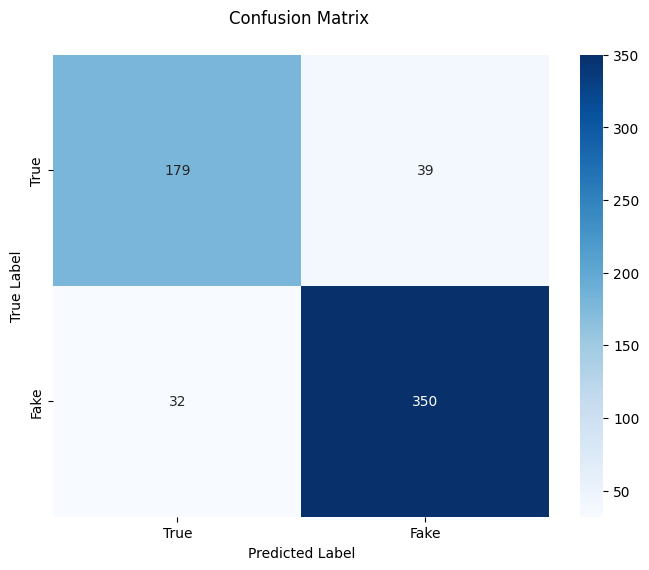

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

# You need to know the class names. Based on your preprocessing:
# label = 1 if label_raw == "credible" else 0
# And since you used num_labels=3, you likely have three labels. 
# Assuming 0: Non-Credible, 1: Credible, and maybe a 2: Undecided (or unused)
# Let's use generic names, but you should use your actual class names.
class_names = ["True", "Fake"] 
# NOTE: Adjust `class_names` if your labels are different.

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title("Confusion Matrix ", y=1.05)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
DATA_PATH ="data/processed/afnd_clean.jsonl"  # change if located somewhere else

data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

len(data)


374532

In [ ]:
N_SAMPLES = 1000
INPUT_FILE="data/processed/afnd_clean.jsonl"  # change if located somewhere else
OUTPUT_FILE = "data/processed/afnd_augmented.jsonl"
import json

samples = []

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= N_SAMPLES:
            break
        samples.append(json.loads(line))

len(samples)


1000

In [ ]:
augmented = []

for item in samples:
    text = item["text"]
    label = item["label"]

    # original
    augmented.append({
        "text": text,
        "label": label
    })

    # dialect
    d = generate_dialect(text)
    if d:
        augmented.append({
            "text": d,
            "label": label
        })

    # adversarial
    a = generate_dialect(text)
    if a:
        augmented.append({
            "text": a,
            "label": label
        })

len(augmented)


150

In [ ]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in augmented:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Saved:", OUTPUT_FILE)


Saved: data/processed/veraarab_augmented_10.jsonl


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "UBC-NLP/MARBERTv2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERTv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from datasets import load_dataset
from collections import Counter

# Path to your augmented JSONL file
DATA_PATH = "data/processed/afnd_augmented.jsonl"   # change later to full file

from datasets import load_dataset

dataset = load_dataset("json", data_files=OUTPUT_FILE)
dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 150
    })
})

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.remove_columns(["text"])
dataset.set_format("torch")


In [ ]:
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

train_ds = dataset["train"]
test_ds = dataset["test"]


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def compute_metrics(p):
    """
    Computes accuracy, F1-score, precision, and recall from the Trainer output.
    p: The EvalPrediction object from the Trainer.
    """
    # The predictions are the logits (raw scores), so we take the argmax to get the class index
    predictions = np.argmax(p.predictions, axis=1)
    
    # The true labels are already in the correct format
    labels = p.label_ids
    
    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)
    f1_micro = f1_score(labels, predictions, average='micro') # Good for imbalanced, general performance
    f1_weighted = f1_score(labels, predictions, average='weighted') # Better for class-specific performance
    precision_w = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall_w = recall_score(labels, predictions, average='weighted', zero_division=0)
    
    # We will compute the confusion matrix separately later as it's not standard for compute_metrics
    
    return {
        "accuracy": accuracy,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted,
        "precision": precision_w,
        "recall": recall_w,
    }
args = TrainingArguments(
    output_dir="./test_run",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,
    logging_steps=1,
    eval_steps=2,
    save_steps=10,
    report_to="none",
   
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


/var/folders/74/3_135jzx2l50jz3vv6cfhd_80000gn/T/ipykernel_1367/4059842233.py:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/anoureen/miniconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
1,0.025400
2,0.003400
3,0.014500
4,0.006000
5,0.001800
6,0.001800
7,0.001500
8,0.001200
9,0.001500
10,0.001100


TrainOutput(global_step=60, training_loss=0.034960943240730555, metrics={'train_runtime': 20.8706, 'train_samples_per_second': 5.75, 'train_steps_per_second': 2.875, 'total_flos': 7893331660800.0, 'train_loss': 0.034960943240730555, 'epoch': 1.0})

In [ ]:
trainer.evaluate()


/Users/anoureen/miniconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.23819181323051453,
 'eval_accuracy': 0.9,
 'eval_f1_micro': 0.9,
 'eval_f1_weighted': 0.9137254901960784,
 'eval_precision': 0.95,
 'eval_recall': 0.9,
 'eval_runtime': 0.4498,
 'eval_samples_per_second': 66.693,
 'eval_steps_per_second': 33.346,
 'epoch': 1.0}

In [ ]:
# Use the predict method on the test dataset
predictions_output = trainer.predict(test_ds)


# Extract predictions (logits) and true labels
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

# Convert logits to class predictions (0, 1, or 2 based on your num_labels=3)
predicted_labels = np.argmax(logits, axis=1)
print(predicted_labels)

/Users/anoureen/miniconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[0 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1]


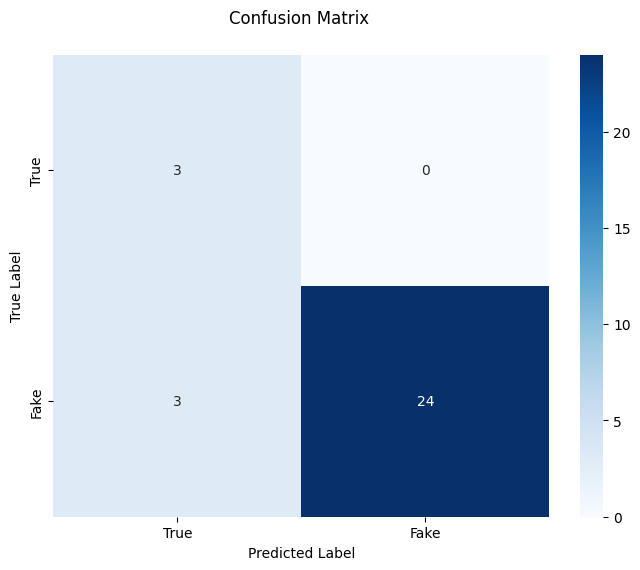

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

# You need to know the class names. Based on your preprocessing:
# label = 1 if label_raw == "credible" else 0
# And since you used num_labels=3, you likely have three labels. 
# Assuming 0: Non-Credible, 1: Credible, and maybe a 2: Undecided (or unused)
# Let's use generic names, but you should use your actual class names.
class_names = ["True", "Fake"] 
# NOTE: Adjust `class_names` if your labels are different.

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title("Confusion Matrix ", y=1.05)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()